<a href="https://colab.research.google.com/github/PedroHS05/Prova-Aprendizagem-de-Maquina-Fatec-2026/blob/main/Prova03.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.utils import resample
from google.colab import drive

In [17]:
# 1. Extração: Conectando ao Drive e lendo os dados
drive.mount('/content/drive')
caminho = '/content/drive/MyDrive/provaicoma/ProuniRelatorioDadosAbertos2020.csv'
base = pd.read_csv(caminho, sep=';', encoding='latin1')

# 2. Tratamento de Nulos
base = base.dropna()

# 3. Laborização (Feature Engineering): Variável Alvo Y
# Bolsa_Integral (1) vs Bolsa_Parcial (0)
base['Y'] = base['TIPO_BOLSA'].apply(lambda x: 1 if 'INTEGRAL' in str(x).upper() else 0)

# 4. Transformação de Qualitativas em Numéricas (Ordinais e Nominais)
mapeamento_turno = {'CURSO A DISTÂNCIA': 0, 'MATUTINO': 1, 'VESPERTINO': 2, 'NOTURNO': 3, 'INTEGRAL': 4}
base['NOME_TURNO_CURSO_BOLSA'] = base['NOME_TURNO_CURSO_BOLSA'].map(mapeamento_turno)

le = LabelEncoder()
colunas_cat = ['MODALIDADE_ENSINO_BOLSA', 'SEXO_BENEFICIARIO', 'RACA_BENEFICIARIO', 'REGIAO_BENEFICIARIO']
for col in colunas_cat:
    base[col] = le.fit_transform(base[col])

# 5. Balanceamento Crítico (Para subir o F1-Score)
df_integral = base[base['Y'] == 1]
df_parcial = base[base['Y'] == 0]

df_integral_downsampled = resample(df_integral,
                                   replace=False,
                                   n_samples=len(df_parcial),
                                   random_state=42)

base_final = pd.concat([df_integral_downsampled, df_parcial])
print("Base equilibrada com sucesso!")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Base equilibrada com sucesso!


/tmp/ipykernel_2880/2400395210.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Y', data=base_final, palette='magma')


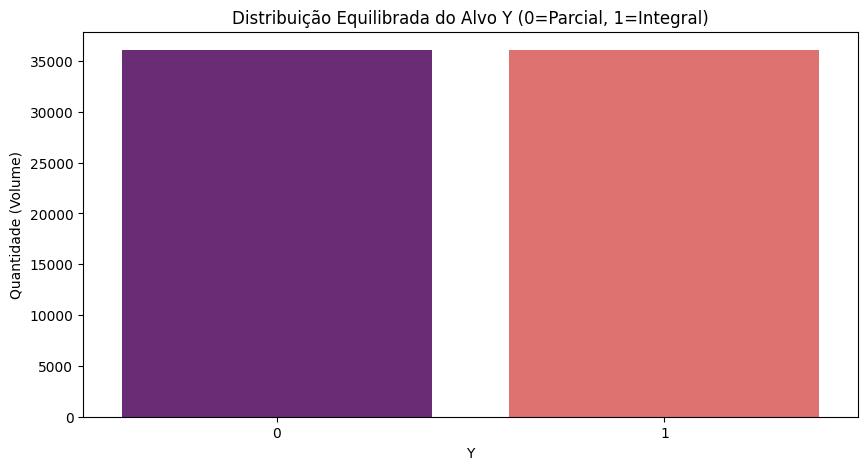

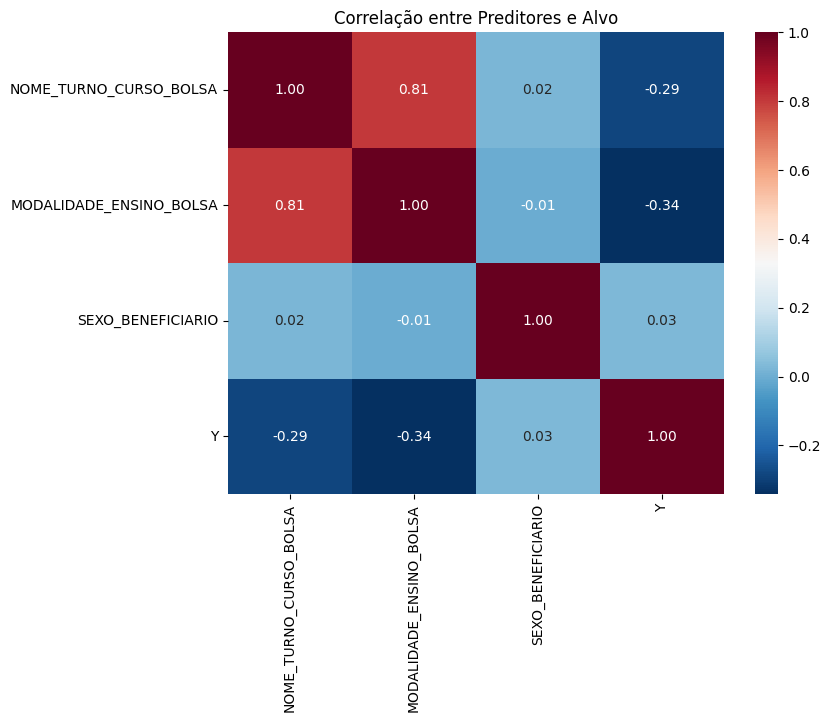

In [18]:
# Gráfico de Volume após balanceamento
plt.figure(figsize=(10,5))
sns.countplot(x='Y', data=base_final, palette='magma')
plt.title('Distribuição Equilibrada do Alvo Y (0=Parcial, 1=Integral)')
plt.ylabel('Quantidade (Volume)')
plt.show()

# Matriz de Correlação
plt.figure(figsize=(8,6))
X_corr = base_final[['NOME_TURNO_CURSO_BOLSA', 'MODALIDADE_ENSINO_BOLSA', 'SEXO_BENEFICIARIO', 'Y']]
sns.heatmap(X_corr.corr(), annot=True, cmap='RdBu_r', fmt='.2f')
plt.title('Correlação entre Preditores e Alvo')
plt.show()

In [19]:
# Seleção de Preditores X
X = base_final[['NOME_TURNO_CURSO_BOLSA', 'MODALIDADE_ENSINO_BOLSA', 'SEXO_BENEFICIARIO', 'REGIAO_BENEFICIARIO']]
y = base_final['Y']

# Divisão Treino e Teste
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Normalização: StandardScaler (Obrigatório)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Treinamento GaussianNB
modelo_nb = GaussianNB()
modelo_nb.fit(X_train_scaled, y_train)

# Previsão
y_pred = modelo_nb.predict(X_test_scaled)

--- RELATÓRIO FINAL DE PERFORMANCE ---
Acurácia: 0.6455

Matriz de Confusão:
[[9833 1008]
 [6667 4141]]

Relatório de Classificação (F1-Score):
              precision    recall  f1-score   support

           0       0.60      0.91      0.72     10841
           1       0.80      0.38      0.52     10808

    accuracy                           0.65     21649
   macro avg       0.70      0.65      0.62     21649
weighted avg       0.70      0.65      0.62     21649



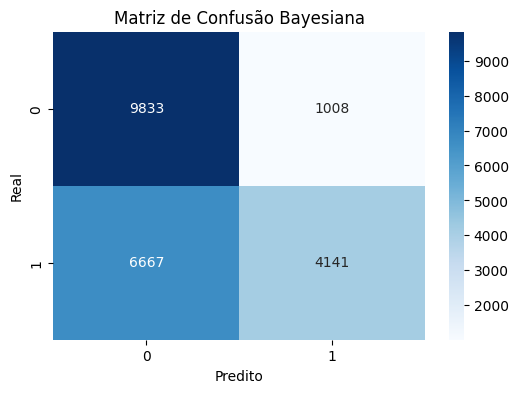

In [20]:
print("--- RELATÓRIO FINAL DE PERFORMANCE ---")
print(f"Acurácia: {accuracy_score(y_test, y_pred):.4f}")
print("\nMatriz de Confusão:")
print(confusion_matrix(y_test, y_pred))
print("\nRelatório de Classificação (F1-Score):")
print(classification_report(y_test, y_pred))

# Plot da Matriz de Confusão Visual
plt.figure(figsize=(6,4))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Blues')
plt.title('Matriz de Confusão Bayesiana')
plt.xlabel('Predito')
plt.ylabel('Real')
plt.show()